# Funciones escalonadas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from ISLP import load_data

In [2]:
Wage = load_data('Wage')
Wage.head()

,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,2006,18,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318063,75.043154
1,2004,24,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255273,70.476020
2,2003,45,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875061,130.982177
3,2003,43,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,5.041393,154.685293
4,2005,50,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.318063,75.043154


In [3]:
Wage.shape

(3000, 11)

In [4]:
Wage.describe()

,year,age,logwage,wage
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,2005.791000,42.414667,4.653905,111.703608
std,2.026167,11.542406,0.351753,41.728595
min,2003.000000,18.000000,3.000000,20.085537
25%,2004.000000,33.750000,4.447158,85.383940
50%,2006.000000,42.000000,4.653213,104.921507
75%,2008.000000,51.000000,4.857332,128.680488
max,2009.000000,80.000000,5.763128,318.342430


In [5]:
age = Wage['age']
wage = Wage['wage']


In [6]:
age_cut, cut_points = pd.qcut(age, q=4,retbins = True)
print('Puntos de corte ', cut_points)

Puntos de corte  [18.   33.75 42.   51.   80.  ]


In [7]:
print('Numero de observaciones por grupo')
print(age_cut.value_counts().sort_index())

Numero de observaciones por grupo
age
(17.999, 33.75]    750
(33.75, 42.0]      759
(42.0, 51.0]       817
(51.0, 80.0]       674
Name: count, dtype: int64


In [8]:
age_cut.cat.categories

IntervalIndex([(17.999, 33.75], (33.75, 42.0], (42.0, 51.0], (51.0, 80.0]], dtype='interval[float64, right]')

In [9]:
X_cat = pd.get_dummies(age_cut,drop_first = True).astype(float)

X= sm.add_constant(X_cat)

print('Matriz de diseño')
print(X.head())

Matriz de diseño
   const  (33.75, 42.0]  (42.0, 51.0]  (51.0, 80.0]
0    1.0            0.0           0.0           0.0
1    1.0            0.0           0.0           0.0
2    1.0            0.0           1.0           0.0
3    1.0            0.0           1.0           0.0
4    1.0            0.0           1.0           0.0


In [10]:
modelo_ls = sm.OLS(wage,X).fit()
print("Regresión por minimos cuadrados")
print(modelo_ls.summary())

Regresión por minimos cuadrados
                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                  0.059
Method:                 Least Squares   F-statistic:                     63.30
Date:                Sun, 30 Aug 2026   Prob (F-statistic):           1.12e-39
Time:                        09:13:48   Log-Likelihood:                -15358.
No. Observations:                3000   AIC:                         3.072e+04
Df Residuals:                    2996   BIC:                         3.075e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         

In [11]:
medias_grupos = (Wage.assign(grupo_edad = age_cut).groupby('grupo_edad',observed = True)['wage'].mean())

medias_grupos

grupo_edad
(17.999, 33.75]     94.158392
(33.75, 42.0]      116.660810
(42.0, 51.0]       119.188665
(51.0, 80.0]       116.571716
Name: wage, dtype: float64

In [12]:
modelo_ls.params

const            94.158392
(33.75, 42.0]    22.502418
(42.0, 51.0]     25.030273
(51.0, 80.0]     22.413324
dtype: float64

In [13]:
modelo_ls.t_test([1,1,0,0])

<class 'statsmodels.stats.contrast.ContrastResults'>
                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0           116.6608      1.470     79.385      0.000     113.779     119.542

In [14]:
age_grid = np.linspace(age.min(),age.max(),1000)


In [15]:
cut_age_grid = pd.cut(age_grid, bins = cut_points, include_lowest = True)

In [16]:
X_grid_cat = pd.get_dummies(cut_age_grid, drop_first = True).astype(float)
X_grid_cat = X_grid_cat.reindex(columns = X_cat.columns,fill_value = 0)
X_grid = sm.add_constant(X_grid_cat, has_constant = 'add')
X_grid = X_grid[X.columns]
X_grid

,const,"(33.75, 42.0]","(42.0, 51.0]","(51.0, 80.0]"
0,1.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0
...,...,...,...,...
995,1.0,0.0,0.0,1.0
996,1.0,0.0,0.0,1.0
997,1.0,0.0,0.0,1.0
998,1.0,0.0,0.0,1.0


In [17]:
pred_ls = modelo_ls.get_prediction(X_grid)
media_ls = pred_ls.predicted_mean

In [18]:
ic_ls = pred_ls.conf_int(alpha= 0.05)

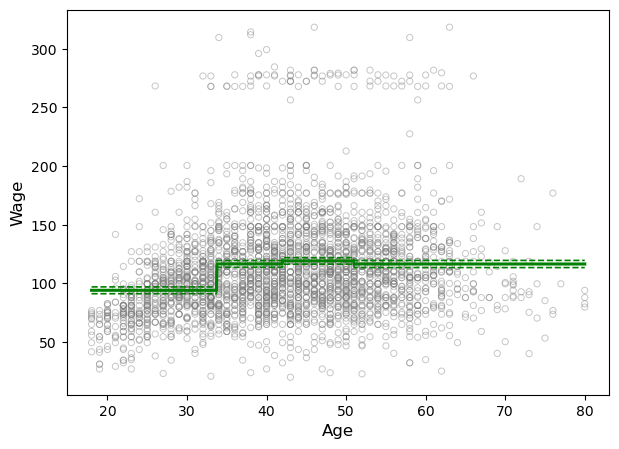

In [19]:
fig, ax = plt.subplots(figsize =(7,5))
ax.scatter(age,wage,facecolors = 'none', edgecolors = 'gray', alpha = 0.45, s=20, linewidth = 0.7)

#Media estimada
ax.plot(age_grid,media_ls, color = 'green', linewidth = 2.2)

#Intervalos de confianza 95%
ax.plot(age_grid, ic_ls[:,0], color = 'green', linestyle ='--', linewidth = 1.2)
ax.plot(age_grid, ic_ls[:,1], color = 'green', linestyle ='--', linewidth = 1.2)
#personalizar
ax.set_xlabel('Age', fontsize = 12)
ax.set_ylabel('Wage', fontsize = 12)
ax.tick_params(axis = 'both', labelsize = 10)
plt.show()

In [20]:
y_bin = (wage > 250).astype(int)
y_bin.head()

0    0
1    0
2    0
3    0
4    0
Name: wage, dtype: int64

In [21]:
y_bin.value_counts()

wage
0    2921
1      79
Name: count, dtype: int64

In [22]:
modelo_logit = sm.Logit(y_bin,X).fit()

Optimization terminated successfully.
         Current function value: 0.118399
         Iterations 9


In [23]:
modelo_logit.params

const           -5.003946
(33.75, 42.0]    1.492401
(42.0, 51.0]     1.665384
(51.0, 80.0]     1.705028
dtype: float64

In [24]:
np.exp(modelo_logit.params)

const            0.006711
(33.75, 42.0]    4.447761
(42.0, 51.0]     5.287706
(51.0, 80.0]     5.501538
dtype: float64

In [25]:
b = modelo_logit.params

probabilidades_grupos = pd.Series([
    1/(1+np.exp(-b.iloc[0])),
    1/(1+np.exp(-(b.iloc[0]+b.iloc[1]))),
    1/(1+np.exp(-(b.iloc[0]+b.iloc[2]))),
    1/(1+np.exp(-(b.iloc[0]+b.iloc[3])))
])

probabilidades_grupos

0    0.006667
1    0.028986
2    0.034272
3    0.035608
dtype: float64

In [26]:
modelo_logit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                   wage   No. Observations:                 3000
Model:                          Logit   Df Residuals:                     2996
Method:                           MLE   Df Model:                            3
Date:                Sun, 30 Aug 2026   Pseudo R-squ.:                 0.02757
Time:                        09:13:48   Log-Likelihood:                -355.20
converged:                       True   LL-Null:                       -365.27
Covariance Type:            nonrobust   LLR p-value:                 0.0001589
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -5.0039      0.449    -11.152      0.000      -5.883      -4.124
(33.75, 42.0]     1.4924      0.498      2.996      0.003       0.516       2.469
(42.0, 51.0]      1.6654      0.488      3.411      0.001       0.709       2.622
(51.0, 80.0]      1.7050      0.495      3.448      0.001       0.736       2.674
=================================================================================
"""

In [27]:
pred_logit = modelo_logit.get_prediction(X_grid)
media_logit = pred_logit.predicted

In [28]:
ic_logit = pred_logit.summary_frame(alpha = 0.05)
ic_logit.head()

,predicted,se,ci_lower,ci_upper
0,0.006667,0.002971,0.002778,0.015914
1,0.006667,0.002971,0.002778,0.015914
2,0.006667,0.002971,0.002778,0.015914
3,0.006667,0.002971,0.002778,0.015914
4,0.006667,0.002971,0.002778,0.015914


In [29]:
ic_logit_low = ic_logit['ci_lower']
ic_logit_high = ic_logit['ci_upper']
ic_logit_low

0      0.002778
1      0.002778
2      0.002778
3      0.002778
4      0.002778
         ...   
995    0.023979
996    0.023979
997    0.023979
998    0.023979
999    0.023979
Name: ci_lower, Length: 1000, dtype: float64

In [30]:
rugh_high = age[y_bin == 1]
rugh_low = age[y_bin == 0]


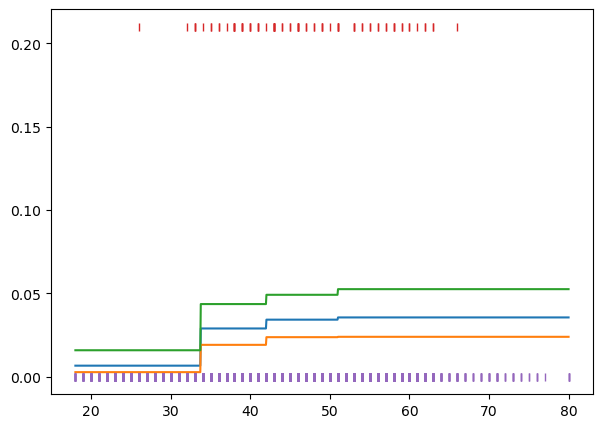

In [31]:
fig = plt.figure(figsize =(7,5))
#plt.scatter(age,wage,facecolors = 'none', edgecolors = 'gray', alpha = 0.45, s=20, linewidth = 0.7)
plt.plot(age_grid,ic_logit['predicted'])
plt.plot(age_grid,ic_logit_low)
plt.plot(age_grid,ic_logit_high)
y_min = 0
y_max = 0.21
plt.plot(rugh_high,np.full(len(rugh_high),y_max),"|")
plt.plot(rugh_low,np.full(len(rugh_low),y_min),"|")
plt.show()

## Ejercicios

### 3.19.1 Ejercicio 1.
Repite el análisis de Wage utilizando los mismos cuatro grupos de edad, pero ahora construye el modelo con cuatro variables indicadoras y sin intercepto.

Ajusta el modelo de mínimos cuadrados.
Interpreta los coeficientes estimados.

RESPUESTA:el primer coeficiente toma el papel del intercepto. y todos los demas parecen ser iguales

Verifica que cada coeficiente coincida con la media salarial del grupo correspondiente.
Ajusta también el modelo logístico para
Transforma los coeficientes logísticos en probabilidades.
Compara las predicciones obtenidas con las del modelo con intercepto.
Explica qué cambia entre ambas parametrizaciones y qué permanece igual.

RESPUESTA: Cambia el numero de variables sin cambiar mucho en los coeficientes ya que parecen recorrerce, en regresion logistica si parece cambiar las probabilidades, pero en ambos modelos la r2 parece ser bastante baja.

In [32]:
age_cut, cut_points = pd.qcut(age, q=4,retbins = True)

X_cat = pd.get_dummies(age_cut,drop_first = False).astype(float)

X= X_cat

print('Matriz de diseño')
print(X.head())

Matriz de diseño
   (17.999, 33.75]  (33.75, 42.0]  (42.0, 51.0]  (51.0, 80.0]
0              1.0            0.0           0.0           0.0
1              1.0            0.0           0.0           0.0
2              0.0            0.0           1.0           0.0
3              0.0            0.0           1.0           0.0
4              0.0            0.0           1.0           0.0


In [33]:
modelo_ls = sm.OLS(wage,X).fit()

In [34]:
medias_grupos = (Wage.assign(grupo_edad = age_cut).groupby('grupo_edad',observed = True)['wage'].mean())
print("Media de los grupos")
print(medias_grupos)
print("Parametros")
print(modelo_ls.params)

Media de los grupos
grupo_edad
(17.999, 33.75]     94.158392
(33.75, 42.0]      116.660810
(42.0, 51.0]       119.188665
(51.0, 80.0]       116.571716
Name: wage, dtype: float64
Parametros
(17.999, 33.75]     94.158392
(33.75, 42.0]      116.660810
(42.0, 51.0]       119.188665
(51.0, 80.0]       116.571716
dtype: float64


In [35]:
X_cat = pd.get_dummies(age_cut,drop_first = False).astype(float)

X= X_cat
y_bin = (wage > 250).astype(int)
modelo_logit = sm.Logit(y_bin,X).fit()

print(modelo_logit.summary())

Optimization terminated successfully.
         Current function value: 0.118399
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                   wage   No. Observations:                 3000
Model:                          Logit   Df Residuals:                     2996
Method:                           MLE   Df Model:                            3
Date:                Sun, 30 Aug 2026   Pseudo R-squ.:                 0.02757
Time:                        09:13:48   Log-Likelihood:                -355.20
converged:                       True   LL-Null:                       -365.27
Covariance Type:            nonrobust   LLR p-value:                 0.0001589
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
(17.999, 33.75]    -5.0039      0.449    -11.152      0.000      -5.883      -4.124
(33.75, 42.0] 

In [36]:
b = modelo_logit.params

probabilidades_grupos = pd.Series([
    1/(1+np.exp(-b.iloc[0])),
    1/(1+np.exp(-(b.iloc[0]+b.iloc[1]))),
    1/(1+np.exp(-(b.iloc[0]+b.iloc[2]))),
    1/(1+np.exp(-(b.iloc[0]+b.iloc[3])))
])

probabilidades_grupos

0    0.006667
1    0.000200
2    0.000238
3    0.000248
dtype: float64

In [37]:
modelo_logit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                   wage   No. Observations:                 3000
Model:                          Logit   Df Residuals:                     2996
Method:                           MLE   Df Model:                            3
Date:                Sun, 30 Aug 2026   Pseudo R-squ.:                 0.02757
Time:                        09:13:48   Log-Likelihood:                -355.20
converged:                       True   LL-Null:                       -365.27
Covariance Type:            nonrobust   LLR p-value:                 0.0001589
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
(17.999, 33.75]    -5.0039      0.449    -11.152      0.000      -5.883      -4.124
(33.75, 42.0]      -3.5115      0.216    -16.230      0.000      -3.936      -3.087
(42.0, 51.0]       -3.3386      0.192    -17.361      0.000      -3.715      -2.962
(51.0, 80.0]       -3.2989      0.208    -15.871      0.000      -3.706      -2.892
===================================================================================
"""

### 3.19.2 Ejercicio 2.
En lugar de dividir Age en cuatro grupos, construye una función escalonada utilizando seis grupos definidos mediante cuantiles.

Ajusta el modelo de mínimos cuadrados.

Grafica la función escalonada estimada con sus intervalos de confianza.

Compara el resultado con el modelo de cuatro grupos.

RESPUESTA: Resulta ser casi igual ya que los ultimos parametros de la regresión tienen parametros iguales

Analiza cómo cambia la flexibilidad del modelo.

Comenta qué ocurre con el número de observaciones dentro de cada intervalo y con la 
incertidumbre de las estimaciones.

RESPUESTA: Parecen ser casi iguaes.

Relaciona tus observaciones con el compromiso entre sesgo y varianza.

RESPUESTA: las predicciones parecen tener bastante sesgo y poca varianza, en ambos modelos.

In [38]:
age_cut, cut_points = pd.qcut(age, q=6,retbins = True)
print('Puntos de corte ', cut_points)

X_cat = pd.get_dummies(age_cut,drop_first = True).astype(float)

X= sm.add_constant(X_cat)

print('Matriz de diseño')
print(X.head())

modelo_ls = sm.OLS(wage,X).fit()
print(modelo_ls.summary())
 

Puntos de corte  [18. 30. 37. 42. 48. 54. 80.]
Matriz de diseño
   const  (30.0, 37.0]  (37.0, 42.0]  (42.0, 48.0]  (48.0, 54.0]  (54.0, 80.0]
0    1.0           0.0           0.0           0.0           0.0           0.0
1    1.0           0.0           0.0           0.0           0.0           0.0
2    1.0           0.0           0.0           1.0           0.0           0.0
3    1.0           0.0           0.0           1.0           0.0           0.0
4    1.0           0.0           0.0           0.0           1.0           0.0
                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.067
Model:                            OLS   Adj. R-squared:                  0.066
Method:                 Least Squares   F-statistic:                     43.14
Date:                Sun, 30 Aug 2026   Prob (F-statistic):           4.61e-43
Time:                        09:13:48   Log-Likelihood:            

In [39]:
age_grid = np.linspace(age.min(),age.max(),1000)


In [40]:
cut_age_grid = pd.cut(age_grid, bins = cut_points, include_lowest = True)

In [41]:
X_grid_cat = pd.get_dummies(cut_age_grid, drop_first = True).astype(float)
X_grid_cat = X_grid_cat.reindex(columns = X_cat.columns,fill_value = 0)
X_grid = sm.add_constant(X_grid_cat, has_constant = 'add')
X_grid = X_grid[X.columns]
X_grid

,const,"(30.0, 37.0]","(37.0, 42.0]","(42.0, 48.0]","(48.0, 54.0]","(54.0, 80.0]"
0,1.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...
995,1.0,0.0,0.0,0.0,0.0,1.0
996,1.0,0.0,0.0,0.0,0.0,1.0
997,1.0,0.0,0.0,0.0,0.0,1.0
998,1.0,0.0,0.0,0.0,0.0,1.0


In [42]:
pred_ls = modelo_ls.get_prediction(X_grid)
media_ls = pred_ls.predicted_mean

In [43]:
ic_ls = pred_ls.conf_int(alpha= 0.05)

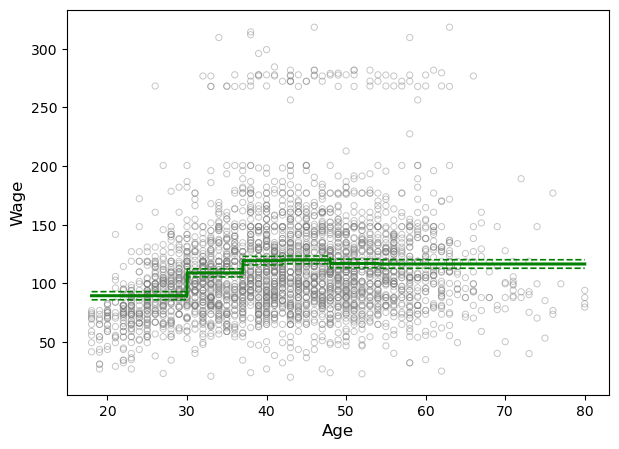

In [44]:
fig, ax = plt.subplots(figsize =(7,5))
ax.scatter(age,wage,facecolors = 'none', edgecolors = 'gray', alpha = 0.45, s=20, linewidth = 0.7)

#Media estimada
ax.plot(age_grid,media_ls, color = 'green', linewidth = 2.2)

#Intervalos de confianza 95%
ax.plot(age_grid, ic_ls[:,0], color = 'green', linestyle ='--', linewidth = 1.2)
ax.plot(age_grid, ic_ls[:,1], color = 'green', linestyle ='--', linewidth = 1.2)
#personalizar
ax.set_xlabel('Age', fontsize = 12)
ax.set_ylabel('Wage', fontsize = 12)
ax.tick_params(axis = 'both', labelsize = 10)
plt.show()

### 3.19.3 Ejercicio 3.
En el análisis anterior definimos


Repite el modelo logístico utilizando ahora los siguientes umbrales:



y


Para cada umbral:

ajusta el modelo logístico utilizando los mismos cuatro grupos de edad;

calcula las probabilidades estimadas para cada grupo;

grafica la función escalonada correspondiente;

compara cómo cambian las probabilidades al aumentar el umbral.

RESPUESTA: Disminuyen la probabilidades al cambiar el grupo.

Explica por qué las probabilidades deben disminuir al utilizar umbrales más altos.

RESPUESTA: Esto pasa ya que al cambiar el umbral aparecen menos datos en cada uno de los grupos lo cual disminuye la probabilidad.

Optimization terminated successfully.
         Current function value: 0.654487
         Iterations 5
Probabildades de Cada Grupo
0    0.289272
1    0.308551
2    0.409449
3    0.422701
dtype: float64
                           Logit Regression Results                           
Dep. Variable:                   wage   No. Observations:                 3000
Model:                          Logit   Df Residuals:                     2994
Method:                           MLE   Df Model:                            5
Date:                Sun, 30 Aug 2026   Pseudo R-squ.:                 0.04824
Time:                        09:13:49   Log-Likelihood:                -1963.5
converged:                       True   LL-Null:                       -2063.0
Covariance Type:            nonrobust   LLR p-value:                 4.574e-41
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
(

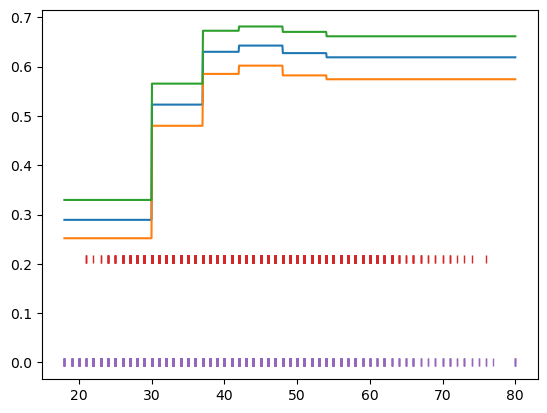

Optimization terminated successfully.
         Current function value: 0.140548
         Iterations 9
Probabildades de Cada Grupo
0    0.005747
1    0.000148
2    0.000233
3    0.000283
dtype: float64
                           Logit Regression Results                           
Dep. Variable:                   wage   No. Observations:                 3000
Model:                          Logit   Df Residuals:                     2994
Method:                           MLE   Df Model:                            5
Date:                Sun, 30 Aug 2026   Pseudo R-squ.:                 0.03084
Time:                        09:13:49   Log-Likelihood:                -421.64
converged:                       True   LL-Null:                       -435.06
Covariance Type:            nonrobust   LLR p-value:                 6.141e-05
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
(

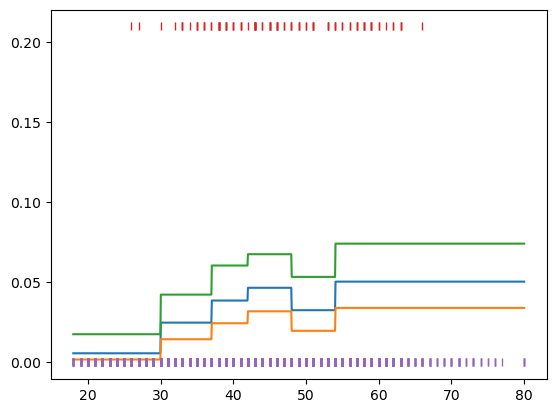

Optimization terminated successfully.
         Current function value: 0.117146
         Iterations 10
Probabildades de Cada Grupo
0    0.001916
1    0.000037
2    0.000068
3    0.000071
dtype: float64
                           Logit Regression Results                           
Dep. Variable:                   wage   No. Observations:                 3000
Model:                          Logit   Df Residuals:                     2994
Method:                           MLE   Df Model:                            5
Date:                Sun, 30 Aug 2026   Pseudo R-squ.:                 0.03786
Time:                        09:13:49   Log-Likelihood:                -351.44
converged:                       True   LL-Null:                       -365.27
Covariance Type:            nonrobust   LLR p-value:                 4.244e-05
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------


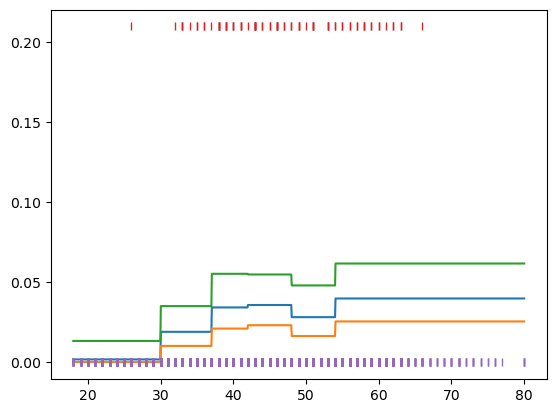

In [45]:
X_cat = pd.get_dummies(age_cut,drop_first = False).astype(float)

X= X_cat
age_grid = np.linspace(age.min(),age.max(),1000)

X_grid_cat = pd.get_dummies(cut_age_grid, drop_first = False).astype(float)
X_grid_cat = X_grid_cat.reindex(columns = X_cat.columns,fill_value = 0)
X_grid = sm.add_constant(X_grid_cat, has_constant = 'add')
X_grid = X_grid[X.columns]


arr = [100,200,250]
for i in arr:
    y_bin = (wage > i).astype(int)
    modelo_logit = sm.Logit(y_bin,X).fit()


    b = modelo_logit.params

    probabilidades_grupos = pd.Series([
        1/(1+np.exp(-b.iloc[0])),
        1/(1+np.exp(-(b.iloc[0]+b.iloc[1]))),
        1/(1+np.exp(-(b.iloc[0]+b.iloc[2]))),
        1/(1+np.exp(-(b.iloc[0]+b.iloc[3])))
    ])
    print("Probabildades de Cada Grupo")
    print(probabilidades_grupos)

    
    print(modelo_logit.summary())



    
    pred_logit = modelo_logit.get_prediction(X_grid)
    media_logit = pred_logit.predicted
    
    ic_logit = pred_logit.summary_frame(alpha = 0.05)
    ic_logit.head()
    
    ic_logit_low = ic_logit['ci_lower']
    ic_logit_high = ic_logit['ci_upper']
    
    rugh_high = age[y_bin == 1]
    rugh_low = age[y_bin == 0]
    fig = plt.figure()
    #plt.scatter(age,wage,facecolors = 'none', edgecolors = 'gray', alpha = 0.45, s=20, linewidth = 0.7)
    plt.plot(age_grid,ic_logit['predicted'])
    plt.plot(age_grid,ic_logit_low)
    plt.plot(age_grid,ic_logit_high)
    y_min = 0
    y_max = 0.21
    plt.plot(rugh_high,np.full(len(rugh_high),y_max),"|")
    plt.plot(rugh_low,np.full(len(rugh_low),y_min),"|")


    plt.show()

### 3.19.4 Ejercicio 4.
Construye dos funciones escalonadas para Age utilizando cuatro grupos:

una mediante pd.qcut();
otra mediante pd.cut().
Para cada caso:

identifica los puntos de corte;

calcula el número de observaciones por grupo;

ajusta un modelo de mínimos cuadrados;

compara las medias estimadas;

RESPUESTA: parecen diferir de una a otra

grafica ambas funciones escalonadas.

Discute las diferencias entre dividir el número de observaciones y dividir el rango de la variable.

RESPUESTA: La principal diferencia es que al tener bastante mas datos una clase que otra pueden quedar desbalanceadas las clase.

Matriz de diseño
   (17.999, 33.75]  (33.75, 42.0]  (42.0, 51.0]  (51.0, 80.0]
0              1.0            0.0           0.0           0.0
1              1.0            0.0           0.0           0.0
2              0.0            0.0           1.0           0.0
3              0.0            0.0           1.0           0.0
4              0.0            0.0           1.0           0.0
Puntos de corte  [18.   33.75 42.   51.   80.  ]
Numero de observaciones por grupo
age
(17.999, 33.75]    750
(33.75, 42.0]      759
(42.0, 51.0]       817
(51.0, 80.0]       674
Name: count, dtype: int64
Media de los grupos
grupo_edad
(17.999, 33.75]     94.158392
(33.75, 42.0]      116.660810
(42.0, 51.0]       119.188665
(51.0, 80.0]       116.571716
Name: wage, dtype: float64
Parametros
(17.999, 33.75]     94.158392
(33.75, 42.0]      116.660810
(42.0, 51.0]       119.188665
(51.0, 80.0]       116.571716
dtype: float64
                            OLS Regression Results                            
Dep

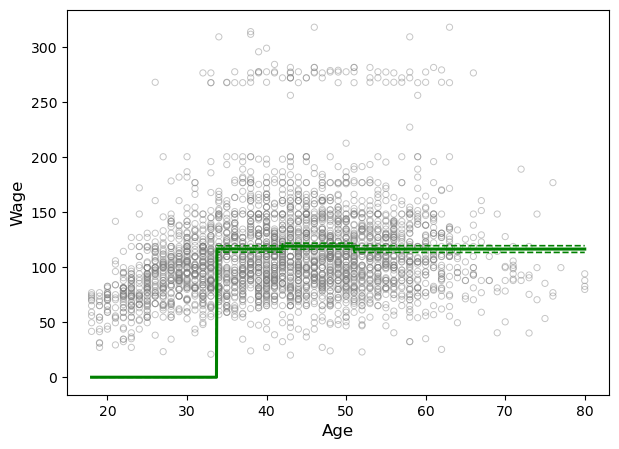

In [46]:
### USANDO QCUT
age_cut, cut_points = pd.qcut(age, q=4,retbins = True)

X_cat = pd.get_dummies(age_cut,drop_first = False).astype(float)

X= X_cat

print('Matriz de diseño')
print(X.head())

modelo_ls = sm.OLS(wage,X).fit()

medias_grupos = (Wage.assign(grupo_edad = age_cut).groupby('grupo_edad',observed = True)['wage'].mean())

print('Puntos de corte ', cut_points)
print('Numero de observaciones por grupo')
print(age_cut.value_counts().sort_index())
print("Media de los grupos")
print(medias_grupos)
print("Parametros")
print(modelo_ls.params)

print(modelo_ls.summary())

#Parte Grafica
#########################################
age_grid = np.linspace(age.min(),age.max(),1000)
cut_age_grid = pd.cut(age_grid, bins = cut_points, include_lowest = True)
X_grid_cat = pd.get_dummies(cut_age_grid, drop_first = True).astype(float)
X_grid_cat = X_grid_cat.reindex(columns = X_cat.columns,fill_value = 0)
X_grid = sm.add_constant(X_grid_cat, has_constant = 'add')
X_grid = X_grid[X.columns]
pred_ls = modelo_ls.get_prediction(X_grid)
media_ls = pred_ls.predicted_mean
ic_ls = pred_ls.conf_int(alpha= 0.05)
fig, ax = plt.subplots(figsize =(7,5))
ax.scatter(age,wage,facecolors = 'none', edgecolors = 'gray', alpha = 0.45, s=20, linewidth = 0.7)

#Media estimada
ax.plot(age_grid,media_ls, color = 'green', linewidth = 2.2)

#Intervalos de confianza 95%
ax.plot(age_grid, ic_ls[:,0], color = 'green', linestyle ='--', linewidth = 1.2)
ax.plot(age_grid, ic_ls[:,1], color = 'green', linestyle ='--', linewidth = 1.2)
#personalizar
ax.set_xlabel('Age', fontsize = 12)
ax.set_ylabel('Wage', fontsize = 12)
ax.tick_params(axis = 'both', labelsize = 10)
plt.show()

Matriz de diseño
   (17.938, 33.5]  (33.5, 49.0]  (49.0, 64.5]  (64.5, 80.0]
0             1.0           0.0           0.0           0.0
1             1.0           0.0           0.0           0.0
2             0.0           1.0           0.0           0.0
3             0.0           1.0           0.0           0.0
4             0.0           0.0           1.0           0.0
Puntos de corte  [17.938 33.5   49.    64.5   80.   ]
Numero de observaciones por grupo
age
(17.938, 33.5]     750
(33.5, 49.0]      1399
(49.0, 64.5]       779
(64.5, 80.0]        72
Name: count, dtype: int64
Media de los grupos
grupo_edad
(17.938, 33.5]     94.158392
(33.5, 49.0]      118.211883
(49.0, 64.5]      117.822951
(64.5, 80.0]      101.798984
Name: wage, dtype: float64
Parametros
(17.938, 33.5]     94.158392
(33.5, 49.0]      118.211883
(49.0, 64.5]      117.822951
(64.5, 80.0]      101.798984
dtype: float64
                            OLS Regression Results                            
Dep. Variable:    

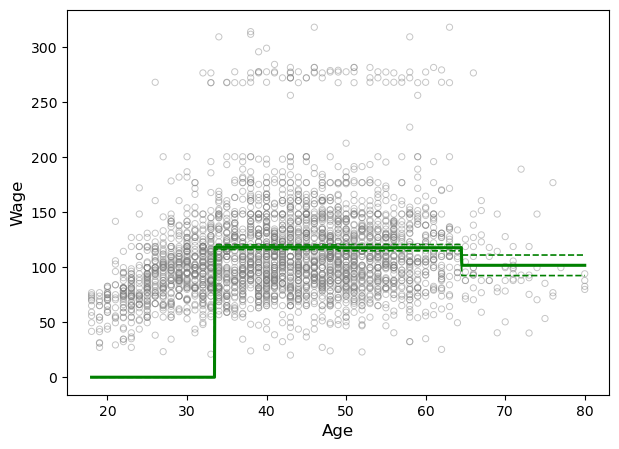

In [47]:

### USANDO CUT
age_cut, cut_points = pd.cut(age, bins=4,retbins = True)

X_cat = pd.get_dummies(age_cut,drop_first = False).astype(float)

X= X_cat

print('Matriz de diseño')
print(X.head())

modelo_ls = sm.OLS(wage,X).fit()

medias_grupos = (Wage.assign(grupo_edad = age_cut).groupby('grupo_edad',observed = True)['wage'].mean())

print('Puntos de corte ', cut_points)
print('Numero de observaciones por grupo')
print(age_cut.value_counts().sort_index())
print("Media de los grupos")
print(medias_grupos)
print("Parametros")
print(modelo_ls.params)

print(modelo_ls.summary())

#Parte Grafica
#########################################
age_grid = np.linspace(age.min(),age.max(),1000)
cut_age_grid = pd.cut(age_grid, bins = cut_points, include_lowest = True)
X_grid_cat = pd.get_dummies(cut_age_grid, drop_first = True).astype(float)
X_grid_cat = X_grid_cat.reindex(columns = X_cat.columns,fill_value = 0)
X_grid = sm.add_constant(X_grid_cat, has_constant = 'add')
X_grid = X_grid[X.columns]
pred_ls = modelo_ls.get_prediction(X_grid)
media_ls = pred_ls.predicted_mean
ic_ls = pred_ls.conf_int(alpha= 0.05)
fig, ax = plt.subplots(figsize =(7,5))
ax.scatter(age,wage,facecolors = 'none', edgecolors = 'gray', alpha = 0.45, s=20, linewidth = 0.7)

#Media estimada
ax.plot(age_grid,media_ls, color = 'green', linewidth = 2.2)

#Intervalos de confianza 95%
ax.plot(age_grid, ic_ls[:,0], color = 'green', linestyle ='--', linewidth = 1.2)
ax.plot(age_grid, ic_ls[:,1], color = 'green', linestyle ='--', linewidth = 1.2)
#personalizar
ax.set_xlabel('Age', fontsize = 12)
ax.set_ylabel('Wage', fontsize = 12)
ax.tick_params(axis = 'both', labelsize = 10)
plt.show()

### 3.19.5 Ejercicio 5.
Utiliza nuevamente el conjunto de datos Wage, pero ahora selecciona otra variable continua como predictor, por ejemplo year.

Explora gráficamente la relación entre esa variable y wage.

Divide el predictor en cuatro grupos mediante cuantiles.

Ajusta una función escalonada mediante mínimos cuadrados.

Interpreta los coeficientes.

Son demasiado parecidos lo que nos dice que posiblemente no haya mucho cambio en su estructura.

Construye una variable binaria basada en wage y ajusta una regresión logística escalonada.

Compara el comportamiento del nuevo predictor con el observado para age.

RESPUESTA: no parece el comportamiento ser mejor en ninguno de los casos ya que parece no haber relación entre las variables.

Discute si una función escalonada parece apropiada para esa relación.

Respuesta: No, no parece haber algun indicio grafico como numerico que induzca a decir que es buena idea hacer esto. 

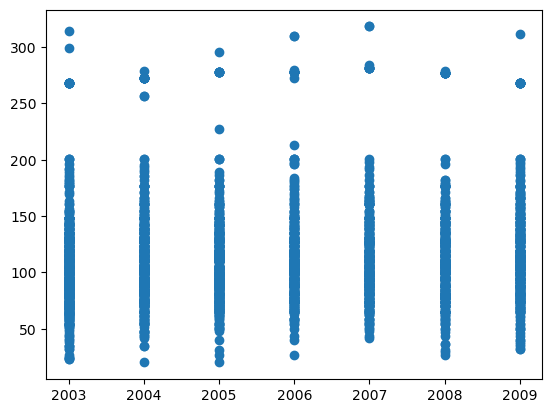

In [48]:
plt.scatter(Wage['year'],Wage['wage'])

Matriz de diseño
   (2002.999, 2004.0]  (2004.0, 2006.0]  (2006.0, 2008.0]  (2008.0, 2009.0]
0                 0.0               1.0               0.0               0.0
1                 1.0               0.0               0.0               0.0
2                 1.0               0.0               0.0               0.0
3                 1.0               0.0               0.0               0.0
4                 0.0               1.0               0.0               0.0
Puntos de corte  [2003. 2004. 2006. 2008. 2009.]
Numero de observaciones por grupo
year
(2002.999, 2004.0]    998
(2004.0, 2006.0]      839
(2006.0, 2008.0]      774
(2008.0, 2009.0]      389
Name: count, dtype: int64
Media de los grupos
grupo_edad
(2002.999, 2004.0]    108.609537
(2004.0, 2006.0]      112.002400
(2006.0, 2008.0]      113.224127
(2008.0, 2009.0]      115.971771
Name: wage, dtype: float64
Parametros
(2002.999, 2004.0]    108.609537
(2004.0, 2006.0]      112.002400
(2006.0, 2008.0]      113.224127
(2008.0, 

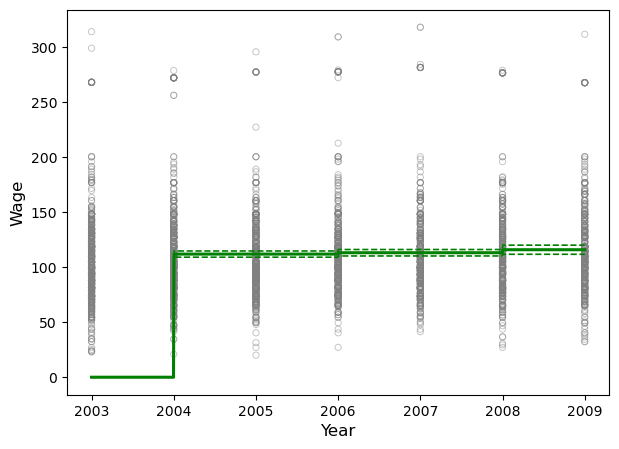

In [49]:

### USANDO CUT
age = Wage['year']
age_cut, cut_points = pd.qcut(age, q=4,retbins = True)

X_cat = pd.get_dummies(age_cut,drop_first = False).astype(float)

X= X_cat

print('Matriz de diseño')
print(X.head())

modelo_ls = sm.OLS(wage,X).fit()

medias_grupos = (Wage.assign(grupo_edad = age_cut).groupby('grupo_edad',observed = True)['wage'].mean())

print('Puntos de corte ', cut_points)
print('Numero de observaciones por grupo')
print(age_cut.value_counts().sort_index())
print("Media de los grupos")
print(medias_grupos)
print("Parametros")
print(modelo_ls.params)

print(modelo_ls.summary())

#Parte Grafica
#########################################
age_grid = np.linspace(age.min(),age.max(),1000)
cut_age_grid = pd.cut(age_grid, bins = cut_points, include_lowest = True)
X_grid_cat = pd.get_dummies(cut_age_grid, drop_first = True).astype(float)
X_grid_cat = X_grid_cat.reindex(columns = X_cat.columns,fill_value = 0)
X_grid = sm.add_constant(X_grid_cat, has_constant = 'add')
X_grid = X_grid[X.columns]
pred_ls = modelo_ls.get_prediction(X_grid)
media_ls = pred_ls.predicted_mean
ic_ls = pred_ls.conf_int(alpha= 0.05)
fig, ax = plt.subplots(figsize =(7,5))
ax.scatter(age,wage,facecolors = 'none', edgecolors = 'gray', alpha = 0.45, s=20, linewidth = 0.7)

#Media estimada
ax.plot(age_grid,media_ls, color = 'green', linewidth = 2.2)

#Intervalos de confianza 95%
ax.plot(age_grid, ic_ls[:,0], color = 'green', linestyle ='--', linewidth = 1.2)
ax.plot(age_grid, ic_ls[:,1], color = 'green', linestyle ='--', linewidth = 1.2)
#personalizar
ax.set_xlabel('Year', fontsize = 12)
ax.set_ylabel('Wage', fontsize = 12)
ax.tick_params(axis = 'both', labelsize = 10)
plt.show()

Optimization terminated successfully.
         Current function value: 0.144934
         Iterations 7
Probabildades de Cada Grupo
0    0.031062
1    0.001187
2    0.001025
3    0.001195
dtype: float64
                           Logit Regression Results                           
Dep. Variable:                   wage   No. Observations:                 3000
Model:                          Logit   Df Residuals:                     2996
Method:                           MLE   Df Model:                            3
Date:                Sun, 30 Aug 2026   Pseudo R-squ.:               0.0005959
Time:                        09:13:49   Log-Likelihood:                -434.80
converged:                       True   LL-Null:                       -435.06
Covariance Type:            nonrobust   LLR p-value:                    0.9148
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------

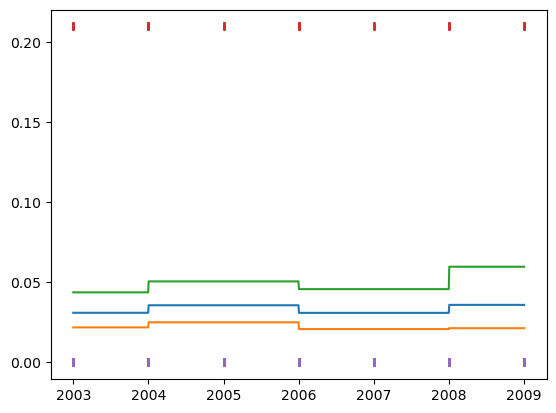

In [50]:
X_cat = pd.get_dummies(age_cut,drop_first = False).astype(float)

X= X_cat
age_grid = np.linspace(age.min(),age.max(),1000)

X_grid_cat = pd.get_dummies(cut_age_grid, drop_first = False).astype(float)
X_grid_cat = X_grid_cat.reindex(columns = X_cat.columns,fill_value = 0)
X_grid = sm.add_constant(X_grid_cat, has_constant = 'add')
X_grid = X_grid[X.columns]


arr = [200]
for i in arr:
    y_bin = (wage > i).astype(int)
    modelo_logit = sm.Logit(y_bin,X).fit()


    b = modelo_logit.params

    probabilidades_grupos = pd.Series([
        1/(1+np.exp(-b.iloc[0])),
        1/(1+np.exp(-(b.iloc[0]+b.iloc[1]))),
        1/(1+np.exp(-(b.iloc[0]+b.iloc[2]))),
        1/(1+np.exp(-(b.iloc[0]+b.iloc[3])))
    ])
    print("Probabildades de Cada Grupo")
    print(probabilidades_grupos)

    
    print(modelo_logit.summary())



    
    pred_logit = modelo_logit.get_prediction(X_grid)
    media_logit = pred_logit.predicted
    
    ic_logit = pred_logit.summary_frame(alpha = 0.05)
    ic_logit.head()
    
    ic_logit_low = ic_logit['ci_lower']
    ic_logit_high = ic_logit['ci_upper']
    
    rugh_high = age[y_bin == 1]
    rugh_low = age[y_bin == 0]
    fig = plt.figure()
    #plt.scatter(age,wage,facecolors = 'none', edgecolors = 'gray', alpha = 0.45, s=20, linewidth = 0.7)
    plt.plot(age_grid,ic_logit['predicted'])
    plt.plot(age_grid,ic_logit_low)
    plt.plot(age_grid,ic_logit_high)
    y_min = 0
    y_max = 0.21
    plt.plot(rugh_high,np.full(len(rugh_high),y_max),"|")
    plt.plot(rugh_low,np.full(len(rugh_low),y_min),"|")


    plt.show()